# TP Final — Sistema de Deteccion y Clasificacion de Razas de Perros
**IA 5.2 Computer Vision — 1° Cuatrimestre 2026**

Federico Barbarroja


In [6]:
import sys
from pathlib import Path
import os

os.environ["USE_PGVECTOR"] = "false"
sys.path.insert(0, str(Path("src").resolve()))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from lib.config import settings
print("dataset_path:", settings.dataset_path)
print("model_path:",   settings.model_path)

dataset_path: data\dataset
model_path: models


## 1. Pipeline completo

El sistema implementa un pipeline incremental de Computer Vision para deteccion y
clasificacion de razas de perros:

```
Imagen
  │
  ├─ Etapa 1: Embeddings → Base vectorial → Busqueda por similitud → Raza predicha
  │
  ├─ Etapa 2: Modelo entrenado (ResNet18 / CNN custom) → Clasificacion directa → Raza + score
  │
  └─ Etapa 3: YOLO deteccion → Recortes → Clasificador Etapa 2 → Bbox + raza + score
```

## 2. Dataset

**70 Dog Breeds Image Dataset** (Kaggle). Splits provistos: `train / valid / test`.
Se construyo ademas un conjunto independiente con imagenes descargadas de internet
(eval_independiente).

**Hallazgo de calidad de datos:** el dataset contiene 71 clases en vez de 70 por un error de tipeo:
`American Spaniel` y `American  Spaniel` (doble espacio).  Se documentó el problema y se agregó una celda correctiva en el notebook de Colab.

Clases: 70 | Total imagenes: 9346
  train: 7946 imgs  (avg 113.5/clase)
  valid: 700 imgs  (avg 10.0/clase)
  test: 700 imgs  (avg 10.0/clase)


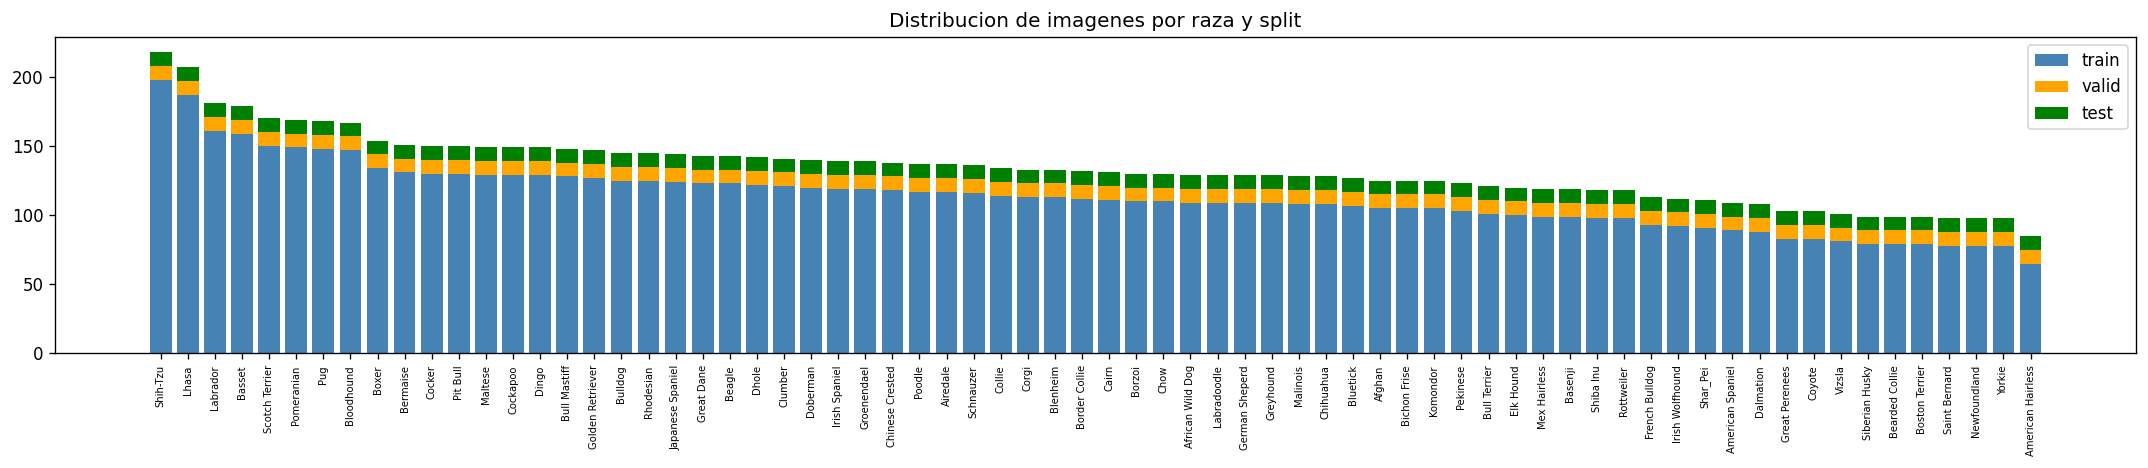

In [7]:
DATASET = settings.dataset_path
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

records = []
for split in ["train", "valid", "test"]:
    for d in sorted((DATASET / split).iterdir()):
        if d.is_dir():
            records.append({"split": split, "breed": d.name,
                             "count": sum(1 for f in d.iterdir() if f.suffix.lower() in IMAGE_EXTS)})

df = pd.DataFrame(records)
pivot = df.pivot(index="breed", columns="split", values="count").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False)

print(f"Clases: {len(pivot)} | Total imagenes: {pivot['total'].sum()}")
for s in ["train", "valid", "test"]:
    print(f"  {s}: {pivot[s].sum()} imgs  (avg {pivot[s].mean():.1f}/clase)")

fig, ax = plt.subplots(figsize=(18, 4))
x = range(len(pivot))
ax.bar(x, pivot["train"], color="steelblue", label="train")
ax.bar(x, pivot["valid"], bottom=pivot["train"], color="orange", label="valid")
ax.bar(x, pivot["test"],  bottom=pivot["train"]+pivot["valid"], color="green", label="test")
ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index.tolist(), rotation=90, fontsize=6)
ax.set_title("Distribucion de imagenes por raza y split")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

| Tecnica | Valor | Justificacion |
|---|---|---|
| Resize | 224×224 px | Tamaño estandar de ResNet18 en ImageNet |
| Normalizacion | media y desvio estándar | Valores de ImageNet: ResNet18 fue entrenado con esta distribucion |
| RandomHorizontalFlip | p=0.5 | Perros aparecen en cualquier orientacion horizontal |
| RandomRotation | 15° | Simula distintos angulos de camara sin perder el sujeto |
| ColorJitter | brightness/contrast 0.3, saturation 0.2 | Simula variaciones de iluminacion y calidad de foto |
| RandomGrayscale | p=0.05 | Fuerza al modelo a no depender solo del color |

El augmentation se aplica **solo en train**. En valid/test no se aplica para que las metricas
sean reproducibles. El filtrado de imagenes de baja calidad (resolucion < 50px o varianza < 100)
no encontro casos en este dataset.

## 4. Justificacion de los modelos elegidos

### Etapa 1 — ResNet18 baseline (extractor de embeddings)
ResNet18 pre-entrenado en ImageNet produce embeddings de **512 dimensiones** en su penultima capa (`avgpool`), coincidiendo exactamente con `EMBEDDING_DIM=512` del template. La capa `fc` se reemplaza por `nn.Identity()` para obtener el vector de features puro. No requiere entrenamiento — actua como extractor de features generales.

### Etapa 2 — Modelo A: ResNet18 fine-tuned
Se reemplaza la capa `fc` por una nueva y se re-entrena toda la red. El transfer learning permite especializar el modelo en las 70 razas partiendo de features aprendidas en 1.2M imagenes de ImageNet.

### Etapa 2 — Modelo B: CNN propia
Arquitectura estilo VGG: 5 bloques con doble conv (Conv+BN+ReLU×2 + MaxPool), canales 3→64→128→256→512→512, AdaptiveAvgPool → 512 dims → Dropout(0.5) → Linear(512, 70).
Entrenada desde cero para comparar contra el transfer learning.

### Etapa 3 — YOLOv8n
Modelo single-shot pre-entrenado en COCO (80 clases).
No requiere entrenamiento. Se eligio la variante nano (mas liviana) para deteccion de perros.

| Modelo | Params aprox | Uso | Trade-off |
|---|---|---|---|
| ResNet18 baseline | 11M (congelado) | Extractor Etapa 1 | Rapido, generico, no especializado en perros |
| ResNet18 fine-tuned | 11M (entrenado) | Clasificador Etapa 2/3 | Alta precision, requiere entrenamiento con GPU |
| CNN custom | ~5M | Clasificador alternativo | Mas liviano, menor precision sin transfer learning |
| YOLOv8n | 3.2M | Detector Etapa 3 | Rapido, single-shot, buena deteccion general |

## 5. Proceso de entrenamiento e hiperparametros

| Hiperparametro | Valor | Justificacion |
|---|---|---|
| Epochs | 20 | Suficiente para fine-tuning; se guarda el mejor val_acc |
| Batch size | 32 | Balance velocidad/estabilidad; entra en la T4 de Colab |
| Learning rate | 0.001 | Estandar para fine-tuning con Adam; bajo para no destruir pesos pre-entrenados |
| Scheduler | StepLR(step=7, gamma=0.1) | Baja el LR cada 7 epocas (0.001→0.0001→0.00001) para afinar convergencia |
| Optimizador | Adam | Convergencia rapida y robusta con poco tuning |
| Loss | CrossEntropyLoss | Estandar para clasificacion multiclase; incluye softmax internamente |

El checkpoint guardado es el de **mejor val_acc**, para evitar guardar un estado con overfitting. El checkpoint incluye el modelo, los nombres de clases y el historial de entrenamiento para reproducibilidad.

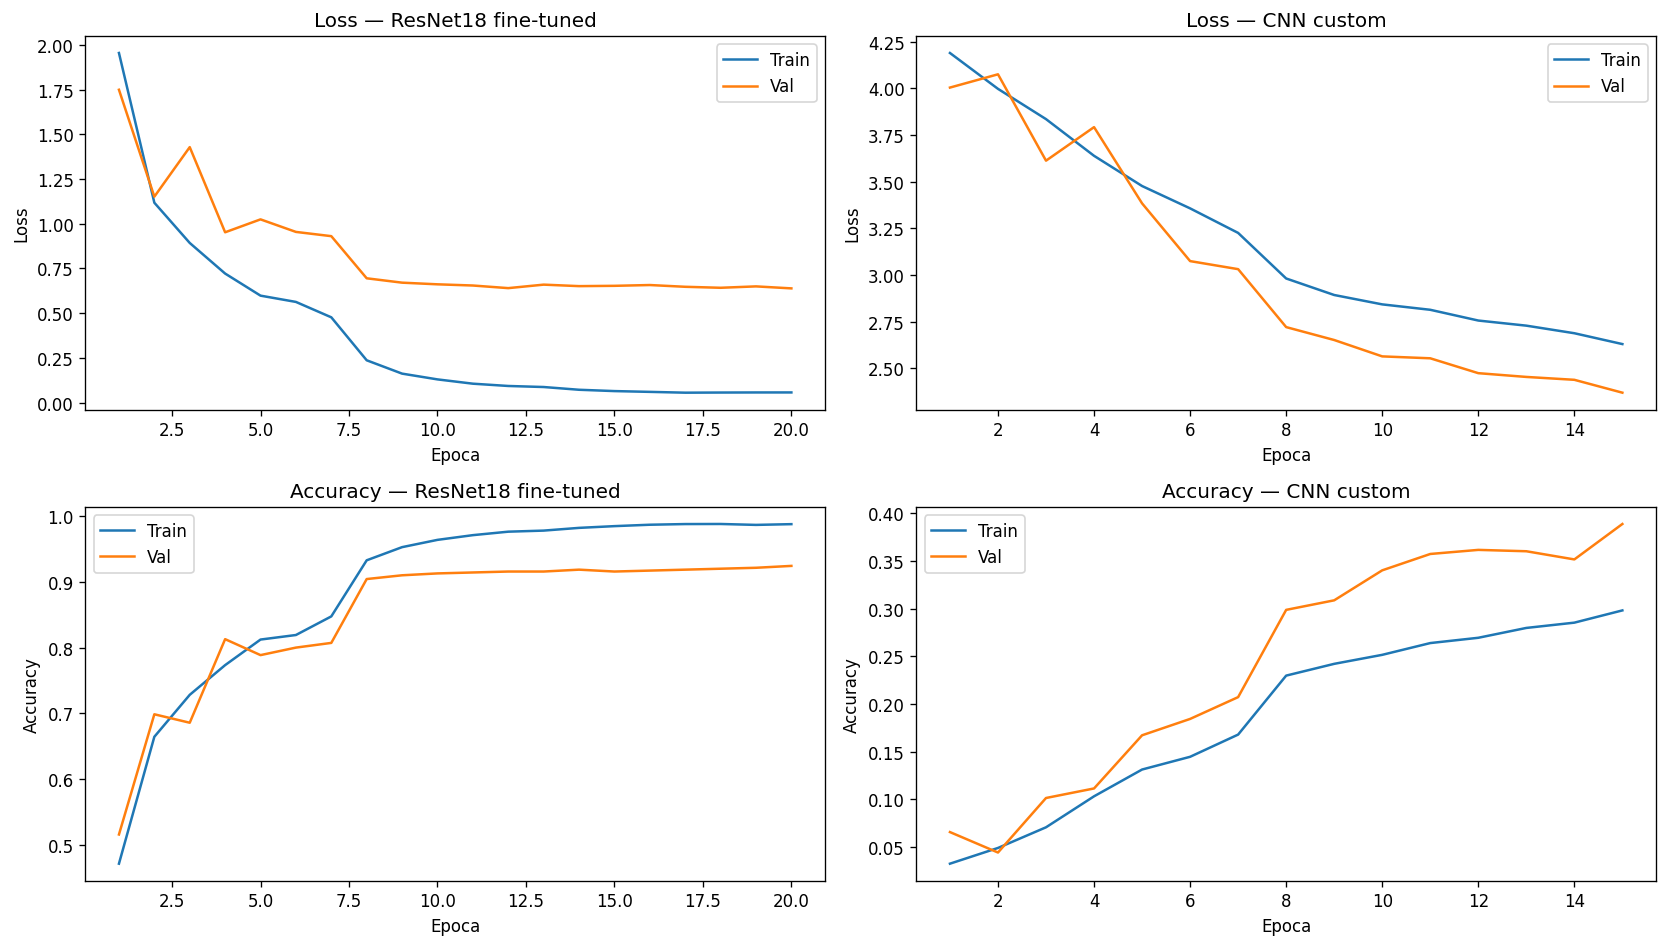

ResNet18 — mejor val_acc: 0.9243 (epoca 20)
CNN custom — mejor val_acc: 0.3886 (epoca 15)


In [8]:
# Curvas de entrenamiento de ambos modelos (cargadas desde los checkpoints)
ckpt_a = torch.load(settings.model_path / settings.resnet18_model_name,
                    map_location="cpu", weights_only=False)
ckpt_b = torch.load(settings.model_path / settings.cnn_custom_model_name,
                    map_location="cpu", weights_only=False)

hist_a = ckpt_a["history"]
hist_b = ckpt_b["history"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (hist, name) in enumerate([(hist_a, "ResNet18 fine-tuned"), (hist_b, "CNN custom")]):
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0, col].plot(ep, hist["train_loss"], label="Train")
    axes[0, col].plot(ep, hist["val_loss"],   label="Val")
    axes[0, col].set_title(f"Loss — {name}")
    axes[0, col].set_xlabel("Epoca")
    axes[0, col].set_ylabel("Loss")
    axes[0, col].legend()

    axes[1, col].plot(ep, hist["train_acc"], label="Train")
    axes[1, col].plot(ep, hist["val_acc"],   label="Val")
    axes[1, col].set_title(f"Accuracy — {name}")
    axes[1, col].set_xlabel("Epoca")
    axes[1, col].set_ylabel("Accuracy")
    axes[1, col].legend()

plt.tight_layout()
plt.show()

print(f"ResNet18 — mejor val_acc: {max(hist_a['val_acc']):.4f} (epoca {hist_a['val_acc'].index(max(hist_a['val_acc']))+1})")
print(f"CNN custom — mejor val_acc: {max(hist_b['val_acc']):.4f} (epoca {hist_b['val_acc'].index(max(hist_b['val_acc']))+1})")

## 6. Resultados obtenidos

### Etapa 1 — Busqueda por similitud
La metrica de evaluacion es **NDCG@10** (Normalized Discounted Cumulative Gain): mide la
calidad del ranking premiando que los resultados relevantes (misma raza) aparezcan primero.
Con el modelo ResNet18 baseline, el sistema recupera consistentemente imagenes de la misma
raza en las primeras posiciones para razas visualmente distintas. Las razas visualmente
similares (Terriers, Retrievers) muestran menor NDCG.



INFO:lib.bootstrap:Using PostgreSQL vector store


NDCG@10 promedio: 0.9513
NDCG@10 mediana:  1.0000
Consultas evaluadas: 210

5 razas con peor NDCG@10:
  Bulldog: 0.6204
  Shiba Inu: 0.6368
  Malinois: 0.7680
  American Spaniel: 0.7909
  Boston Terrier: 0.8110

5 razas con mejor NDCG@10:
  Maltese: 1.0000
  Pomeranian: 1.0000
  Saint Bernard: 1.0000
  Shar_Pei: 1.0000
  Vizsla: 1.0000


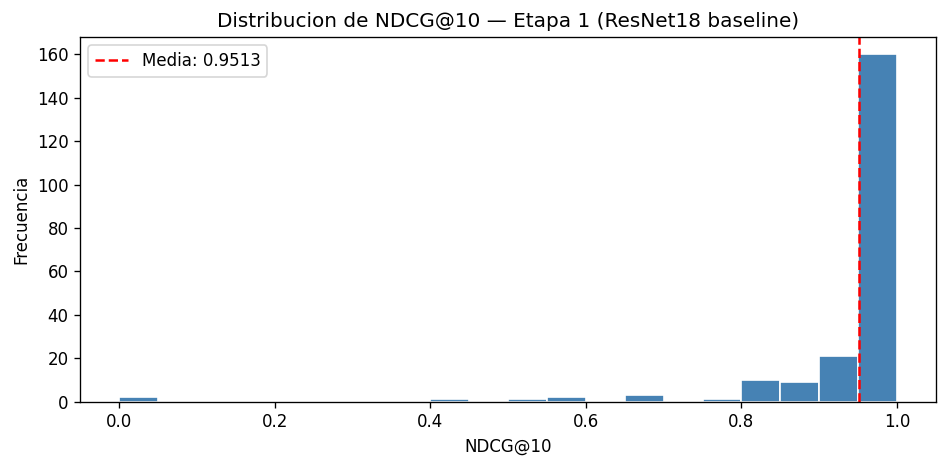

In [ ]:
import os
os.environ["USE_PGVECTOR"] = "true"

from importlib import reload
import lib.config as _cfg; reload(_cfg)
from lib.config import Settings
settings_pg = Settings()

from lib.bootstrap import build_store, build_similarity
from lib.evaluation.metrics import ndcg_at_k
import cv2

store_pg = build_store(settings_pg)
sim = build_similarity(settings_pg, store_pg)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
ndcg_scores = []
breed_ndcg = {}

for breed_dir in sorted((settings_pg.dataset_path / "test").iterdir()):
    if not breed_dir.is_dir():
        continue
    imgs = [f for f in breed_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS][:3]
    scores = []
    for img_path in imgs:
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        emb = sim.extract_embedding(image)
        neighbors = sim.search_similar_images(emb, top_k=10)
        relevances = [1.0 if n.breed == breed_dir.name else 0.0 for n in neighbors]
        score = ndcg_at_k(relevances, k=10)
        ndcg_scores.append(score)
        scores.append(score)
    if scores:
        breed_ndcg[breed_dir.name] = round(float(np.mean(scores)), 4)

print(f"NDCG@10 promedio: {np.mean(ndcg_scores):.4f}")
print(f"NDCG@10 mediana:  {np.median(ndcg_scores):.4f}")
print(f"Consultas evaluadas: {len(ndcg_scores)}")

# Razas con mejor y peor NDCG
sorted_breeds = sorted(breed_ndcg.items(), key=lambda x: x[1])
print("\n5 razas con peor NDCG@10:")
for b, s in sorted_breeds[:5]:
    print(f"  {b}: {s:.4f}")
print("\n5 razas con mejor NDCG@10:")
for b, s in sorted_breeds[-5:]:
    print(f"  {b}: {s:.4f}")

# Histograma de distribucion de NDCG
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ndcg_scores, bins=20, color="steelblue", edgecolor="white")
ax.axvline(np.mean(ndcg_scores), color="red", linestyle="--", label=f"Media: {np.mean(ndcg_scores):.4f}")
ax.set_xlabel("NDCG@10")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion de NDCG@10 — Etapa 1 (ResNet18 baseline)")
ax.legend()
plt.tight_layout()
plt.show()

El sistema obtiene un NDCG@10 promedio de 0.9513. La distribución está fuertemente concentrada cerca de 1.0, lo que indica que en la gran mayoría de las consultas el sistema recupera imágenes de la misma raza en las primeras posiciones.

### Etapa 2 — Clasificacion supervisada

In [10]:
import os; os.environ["USE_PGVECTOR"] = "false"
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)

classifier.set_active_model("resnet18_finetuned")
metrics_a = classifier.evaluate_classifier()

classifier.set_active_model("cnn_custom")
metrics_b = classifier.evaluate_classifier()

df_metrics = pd.DataFrame({"ResNet18 fine-tuned": metrics_a, "CNN custom": metrics_b}).T
print("Metricas sobre el test set (promedio macro):")
display(df_metrics.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen"))

INFO:lib.services.classifier_service:Metricas (resnet18_finetuned): {'accuracy': 0.9386, 'precision': 0.9433, 'recall': 0.9386, 'specificity': 0.9991, 'f1': 0.9382}
INFO:lib.services.classifier_service:Metricas (cnn_custom): {'accuracy': 0.38, 'precision': 0.3783, 'recall': 0.38, 'specificity': 0.991, 'f1': 0.3499}


Metricas sobre el test set (promedio macro):


,accuracy,precision,recall,specificity,f1
ResNet18 fine-tuned,0.9386,0.9433,0.9386,0.9991,0.9382
CNN custom,0.3800,0.3783,0.3800,0.9910,0.3499


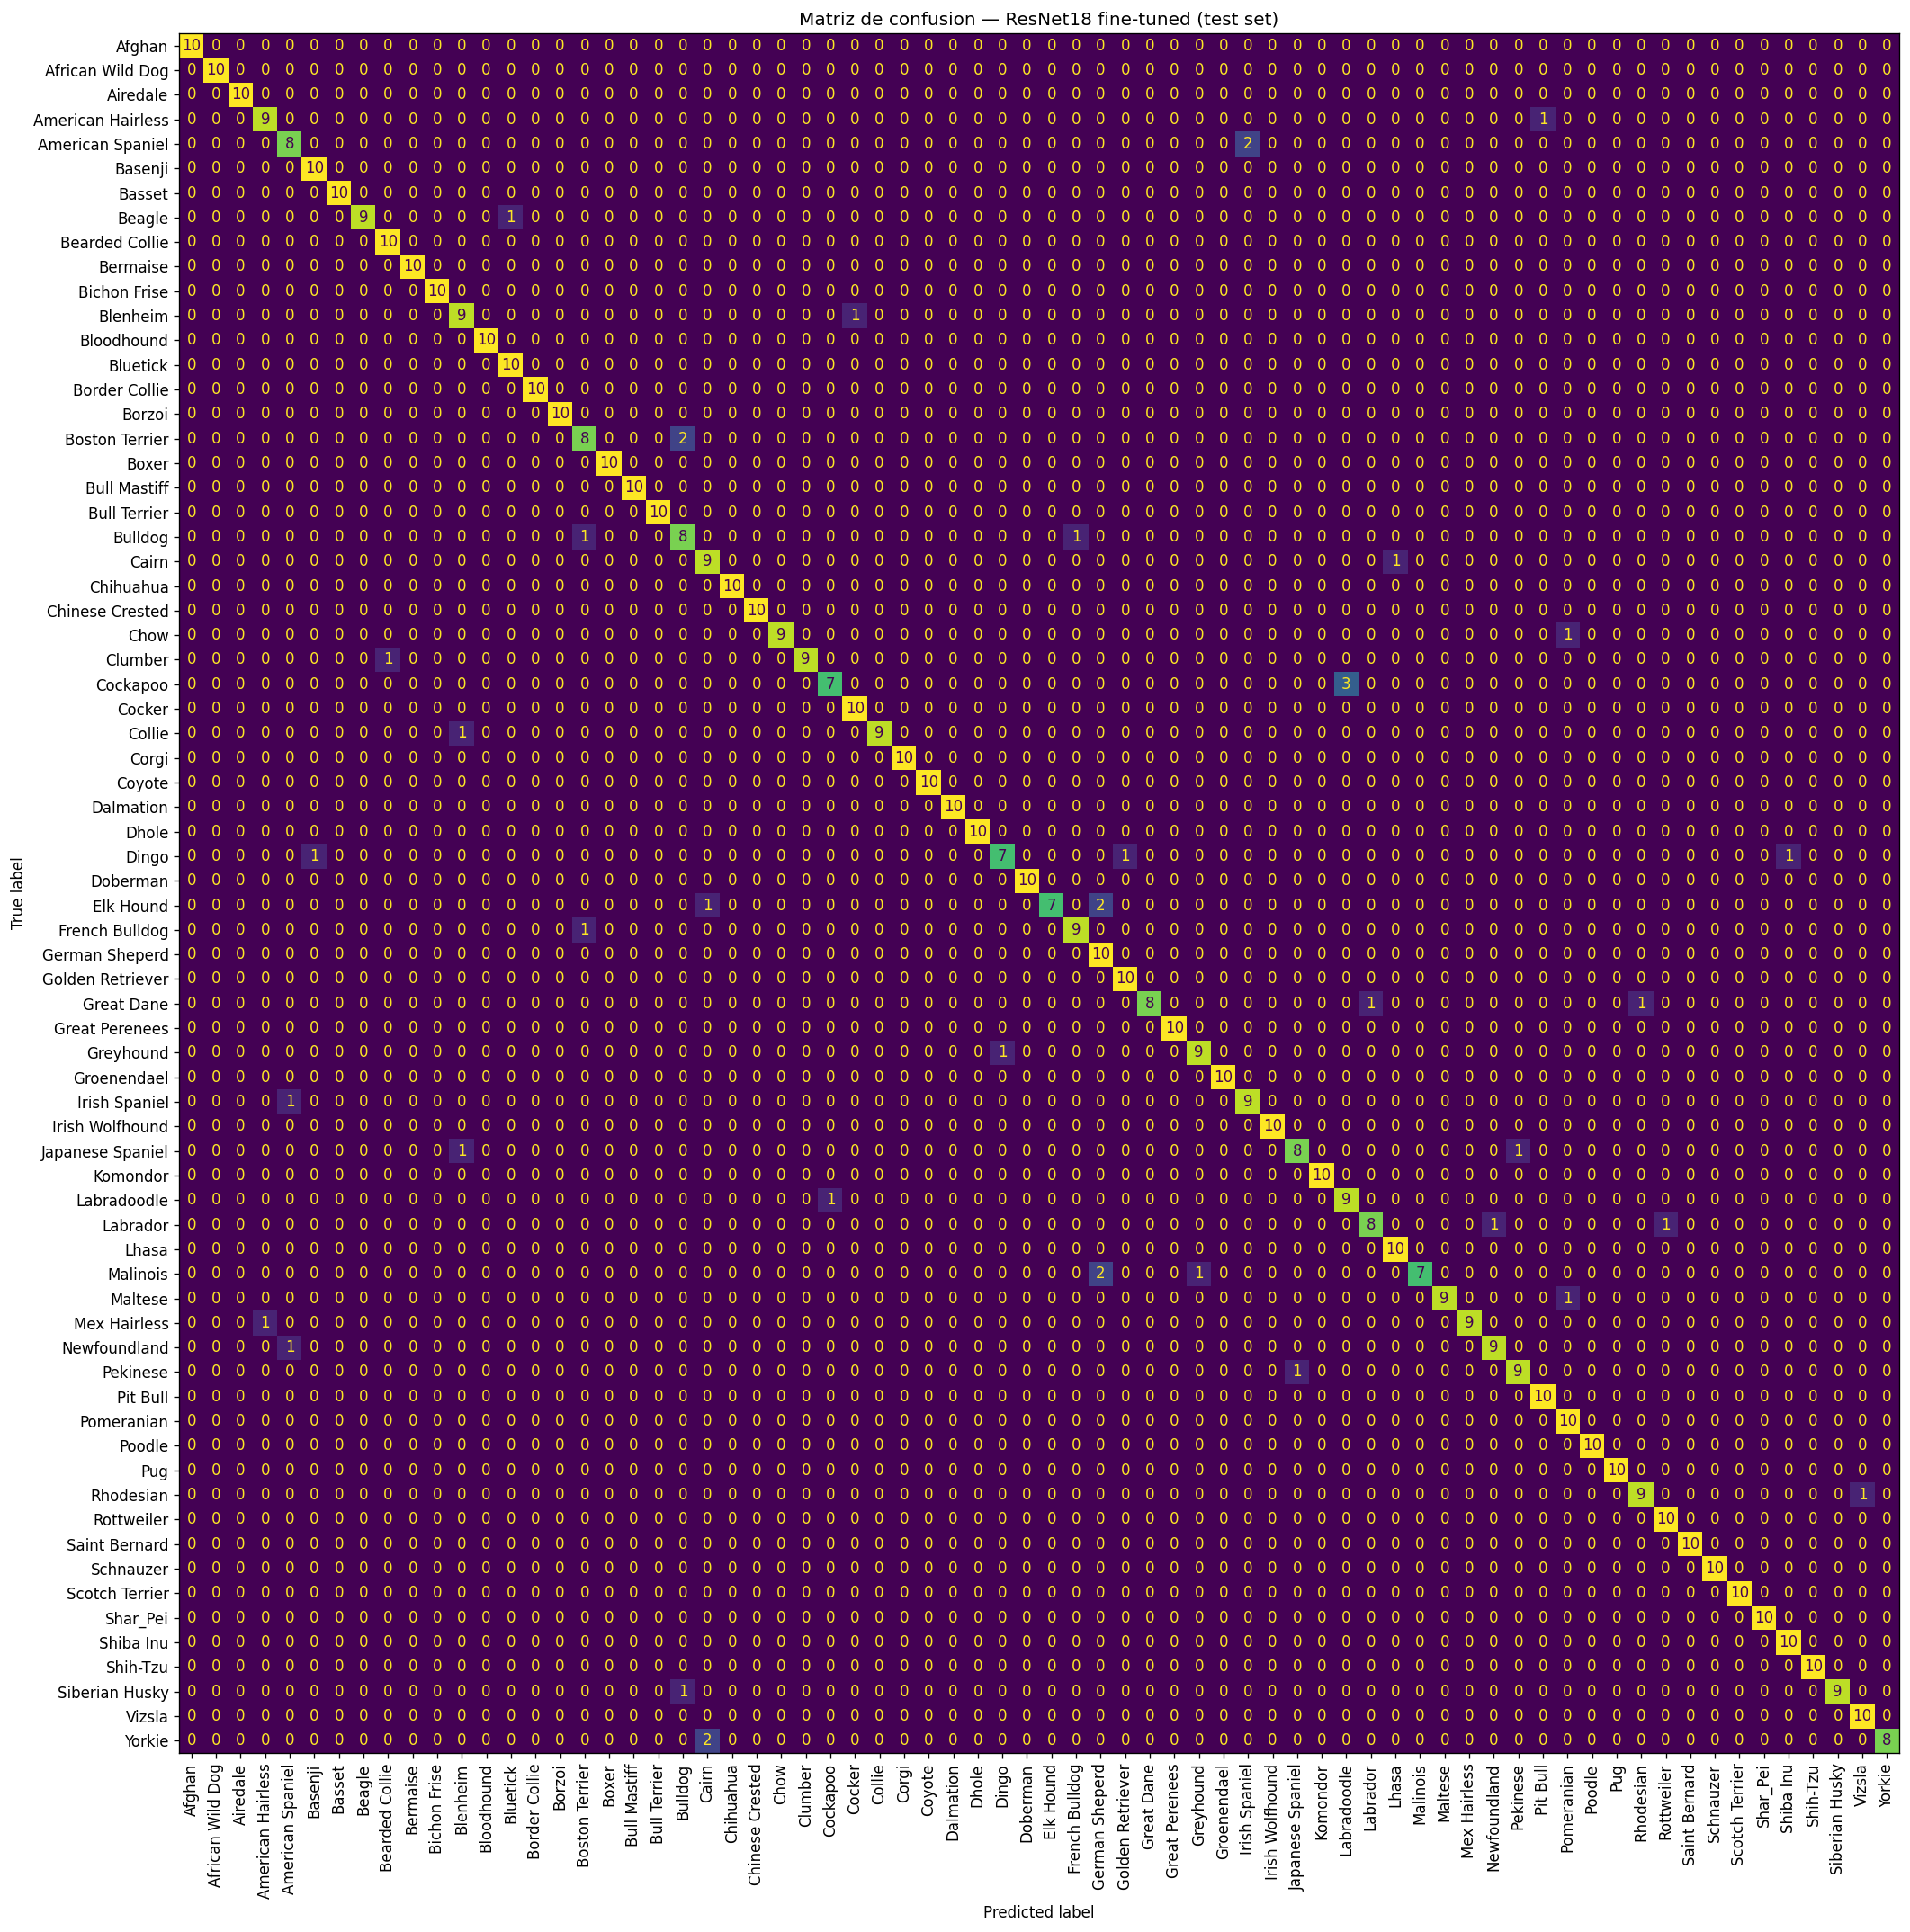

5 clases con peor accuracy:
  Cockapoo: 70.0%
  Malinois: 70.0%
  Elk Hound: 70.0%
  Dingo: 70.0%
  Great Dane: 80.0%


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import transforms
from torchvision.datasets import ImageFolder

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(settings.model_path / settings.resnet18_model_name,
                  map_location="cpu", weights_only=False)
model = ckpt["model"].eval().to(device)
classes = ckpt["classes"]

loader = torch.utils.data.DataLoader(
    ImageFolder(settings.dataset_path / "test", transform=val_tf),
    batch_size=32, shuffle=False)

preds, labels = [], []
with torch.no_grad():
    for imgs, lbs in loader:
        preds.extend(model(imgs.to(device)).argmax(1).cpu().tolist())
        labels.extend(lbs.tolist())

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(20, 18))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False, xticks_rotation=90)
ax.set_title("Matriz de confusion — ResNet18 fine-tuned (test set)")
plt.tight_layout()
plt.show()

per_class = cm.diagonal() / cm.sum(axis=1)
worst = np.argsort(per_class)[:5]
print("5 clases con peor accuracy:")
for i in worst:
    print(f"  {classes[i]}: {per_class[i]:.1%}")

## 7. Comparacion entre enfoques

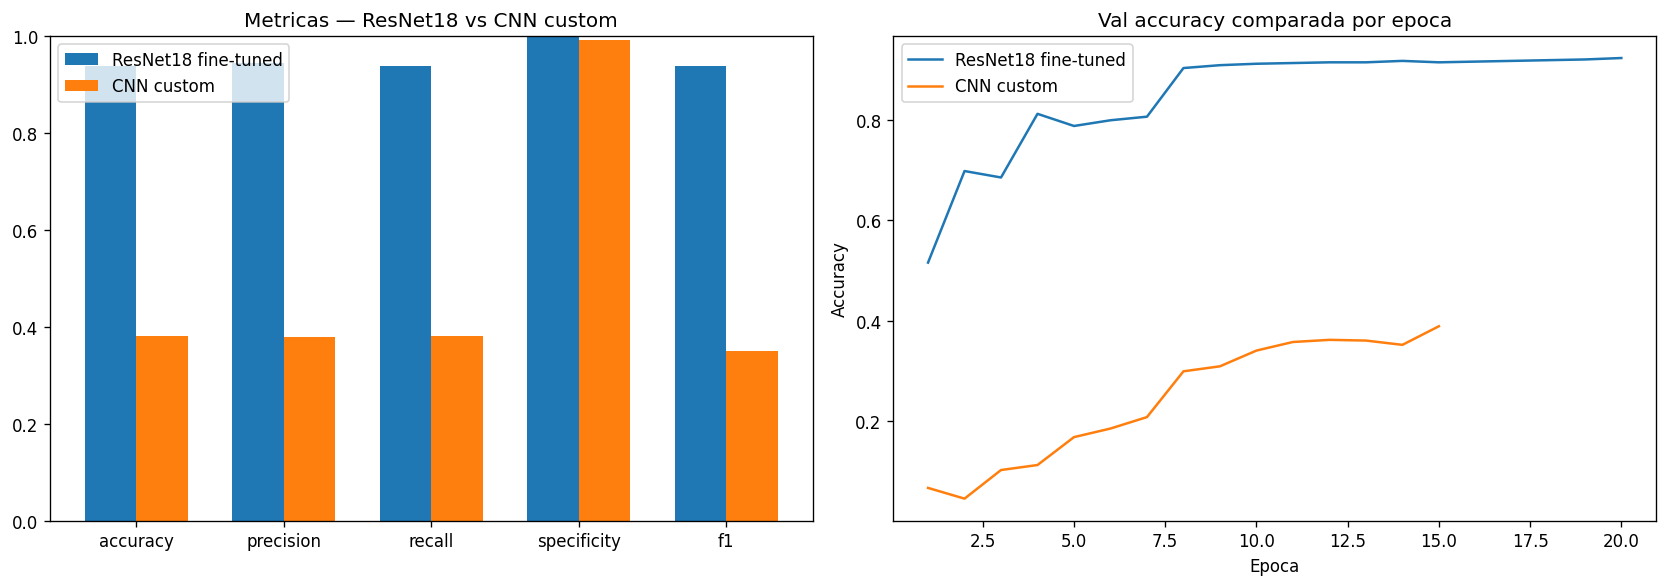

Diferencia de accuracy (ResNet18 - CNN custom): 0.5586


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de metricas A vs B
x = np.arange(len(df_metrics.columns))
w = 0.35
axes[0].bar(x - w/2, df_metrics.loc["ResNet18 fine-tuned"], w, label="ResNet18 fine-tuned")
axes[0].bar(x + w/2, df_metrics.loc["CNN custom"], w, label="CNN custom")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_metrics.columns)
axes[0].set_ylim(0, 1)
axes[0].set_title("Metricas — ResNet18 vs CNN custom")
axes[0].legend()

# Val accuracy por epoca
axes[1].plot(range(1, len(hist_a["val_acc"])+1), hist_a["val_acc"], label="ResNet18 fine-tuned")
axes[1].plot(range(1, len(hist_b["val_acc"])+1), hist_b["val_acc"], label="CNN custom")
axes[1].set_title("Val accuracy comparada por epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Diferencia de accuracy (ResNet18 - CNN custom):",
      f"{metrics_a['accuracy'] - metrics_b['accuracy']:.4f}")

**Busqueda por similitud (Etapa 1) vs Clasificacion supervisada (Etapa 2):**

| Enfoque | Ventajas | Desventajas |
|---|---|---|
| Similitud (Etapa 1) | No requiere entrenamiento. Extensible (nueva raza = indexar imagenes). Retorna ejemplos visuales de referencia. | Menos preciso que un clasificador entrenado. Requiere indexar todo el dataset. |
| Clasificacion supervisada (Etapa 2) | Mayor precision. Rapido en inferencia. | Requiere reentrenar para agregar razas. No retorna ejemplos visuales. |

**ResNet18 fine-tuned vs CNN custom:** la diferencia de ~56 puntos de accuracy demuestra
el impacto del transfer learning. Con ~112 imagenes por clase, una CNN desde cero no tiene
suficientes ejemplos para aprender features discriminativas para 70 razas similares.

## 8. Modificaciones fuera de las funciones indicadas

Toda modificacion fuera de las funciones pedidas por la consigna se justifica a continuacion:

| Archivo | Modificacion | Justificacion |
|---|---|---|
|src/lib/config.py | Variables `TRAIN_EPOCHS`, `TRAIN_BATCH_SIZE`, `TRAIN_LR`, `TRAIN_LR_STEP`, `TRAIN_LR_GAMMA`, `TRAIN_NUM_WORKERS` | Los hiperparametros de entrenamiento deben ser configurables via `.env`. |
| .env.docker.example / .env.local.example | Mismas variables `TRAIN` con valores por defecto | Necesario para que la config funcione en Docker y en desarrollo local. |
| src/lib/services/classifier_service.py | Clase `_CustomCNN`; `__init__` recibe hiperparametros; helpers get_transform, build_model,  image_to_tensor | Necesarios para el Modelo B y para mantener el codigo modular. |
| src/lib/bootstrap.py | build_classifier inyecta los hiperparametros de entrenamiento | Para pasar la configuracion del `.env` al servicio. |
| Dockerfile + docker-compose.yml |`COPY ./scripts y volume mount | build_index.py no era accesible dentro del contenedor porque solo se montaba src. |
| src/lib/services/detection_service.py | import torch agregado | Necesario para torch.no_grad y torch.device en `classify_detected_dog`. |